Dimensões do dataset: (918, 12)

Distribuição da variável target (HeartDisease):
HeartDisease
1    508
0    410
Name: count, dtype: int64
Treino - Shape: (734, 11)
Distribuição no treino (ORIGINAL):
HeartDisease
1    406
0    328
Name: count, dtype: int64
Treino após SMOTE - Shape: (812, 11)
Distribuição no treino (BALANCEADO):
HeartDisease
1    406
0    406
Name: count, dtype: int64
KNN - DADOS ORIGINAIS
Melhor K encontrado: 17
Acurácia: 0.8913
KNN - DADOS BALANCEADOS
Melhor K encontrado: 7
Acurácia: 0.9076
REGRESSÃO LOGÍSTICA - DADOS ORIGINAIS
Acurácia: 0.8696
REGRESSÃO LOGÍSTICA - DADOS BALANCEADOS
Acurácia: 0.8641
RANDOM FOREST - DADOS ORIGINAIS
Acurácia: 0.8750
RANDOM FOREST - DADOS BALANCEADOS
Acurácia: 0.8967
MATRIZES DE CONFUSÃO - DADOS ORIGINAIS


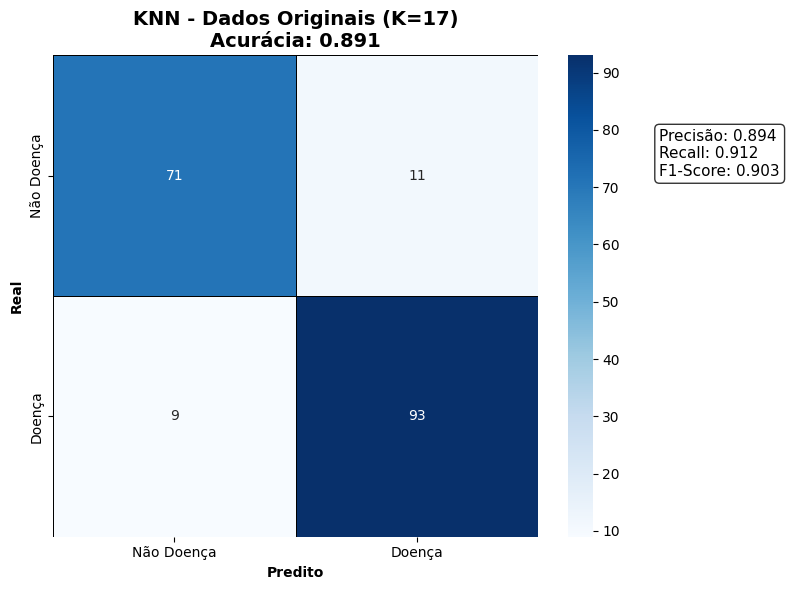


KNN - Dados Originais (K=17):
   Verdadeiros Negativos (TN): 71
   Falsos Positivos (FP): 11
   Falsos Negativos (FN): 9
   Verdadeiros Positivos (TP): 93
   Acurácia: 0.891
   Precisão: 0.894
   Recall: 0.912
   F1-Score: 0.903
--------------------------------------------------


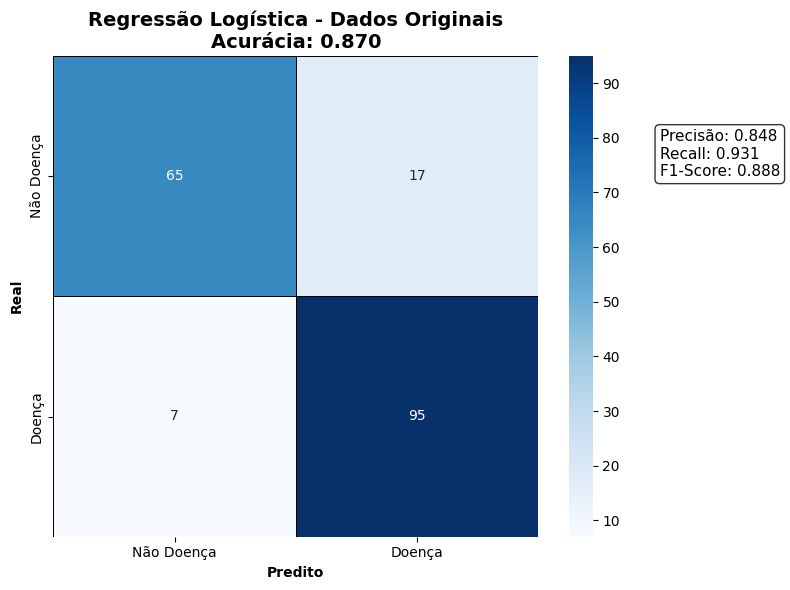


Regressão Logística - Dados Originais:
   Verdadeiros Negativos (TN): 65
   Falsos Positivos (FP): 17
   Falsos Negativos (FN): 7
   Verdadeiros Positivos (TP): 95
   Acurácia: 0.870
   Precisão: 0.848
   Recall: 0.931
   F1-Score: 0.888
--------------------------------------------------


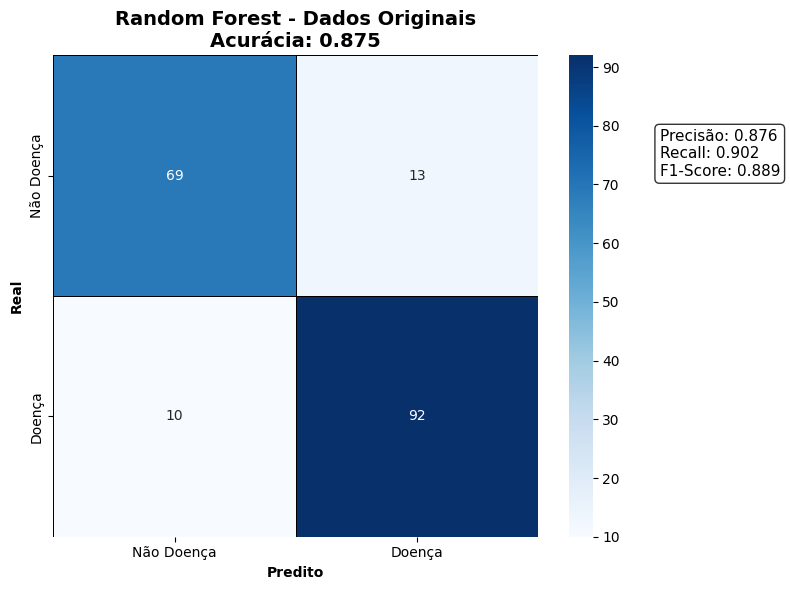


Random Forest - Dados Originais:
   Verdadeiros Negativos (TN): 69
   Falsos Positivos (FP): 13
   Falsos Negativos (FN): 10
   Verdadeiros Positivos (TP): 92
   Acurácia: 0.875
   Precisão: 0.876
   Recall: 0.902
   F1-Score: 0.889
--------------------------------------------------
MATRIZES DE CONFUSÃO - DADOS BALANCEADOS


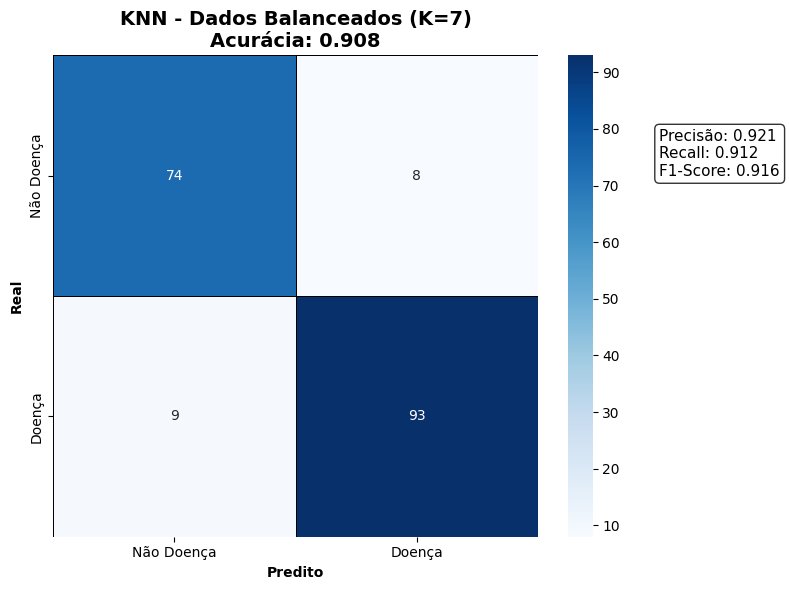


KNN - Dados Balanceados (K=7):
   Verdadeiros Negativos (TN): 74
   Falsos Positivos (FP): 8
   Falsos Negativos (FN): 9
   Verdadeiros Positivos (TP): 93
   Acurácia: 0.908
   Precisão: 0.921
   Recall: 0.912
   F1-Score: 0.916
--------------------------------------------------


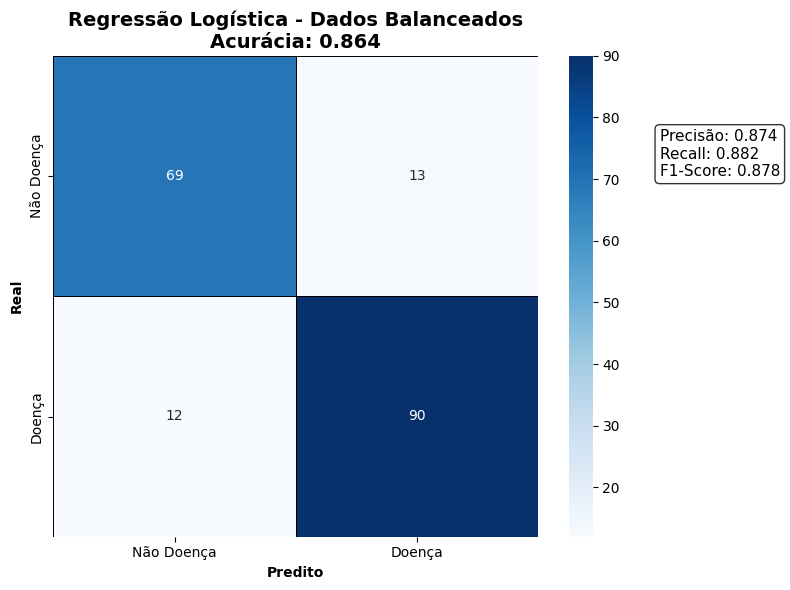


Regressão Logística - Dados Balanceados:
   Verdadeiros Negativos (TN): 69
   Falsos Positivos (FP): 13
   Falsos Negativos (FN): 12
   Verdadeiros Positivos (TP): 90
   Acurácia: 0.864
   Precisão: 0.874
   Recall: 0.882
   F1-Score: 0.878
--------------------------------------------------


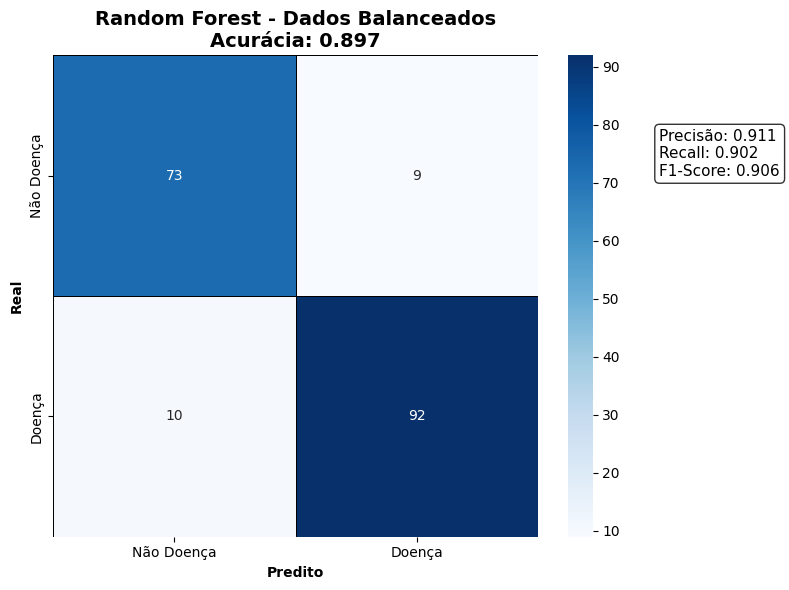


Random Forest - Dados Balanceados:
   Verdadeiros Negativos (TN): 73
   Falsos Positivos (FP): 9
   Falsos Negativos (FN): 10
   Verdadeiros Positivos (TP): 92
   Acurácia: 0.897
   Precisão: 0.911
   Recall: 0.902
   F1-Score: 0.906
--------------------------------------------------
COMPARAÇÃO FINAL - ORIGINAL vs BALANCEADO

Comparação de Acurácia:
                Modelo  Acurácia_Original  Acurácia_Balanceado  Diferença
0                  KNN           0.891304             0.907609   0.016304
1        Random Forest           0.875000             0.896739   0.021739
2  Regressão Logística           0.869565             0.864130  -0.005435


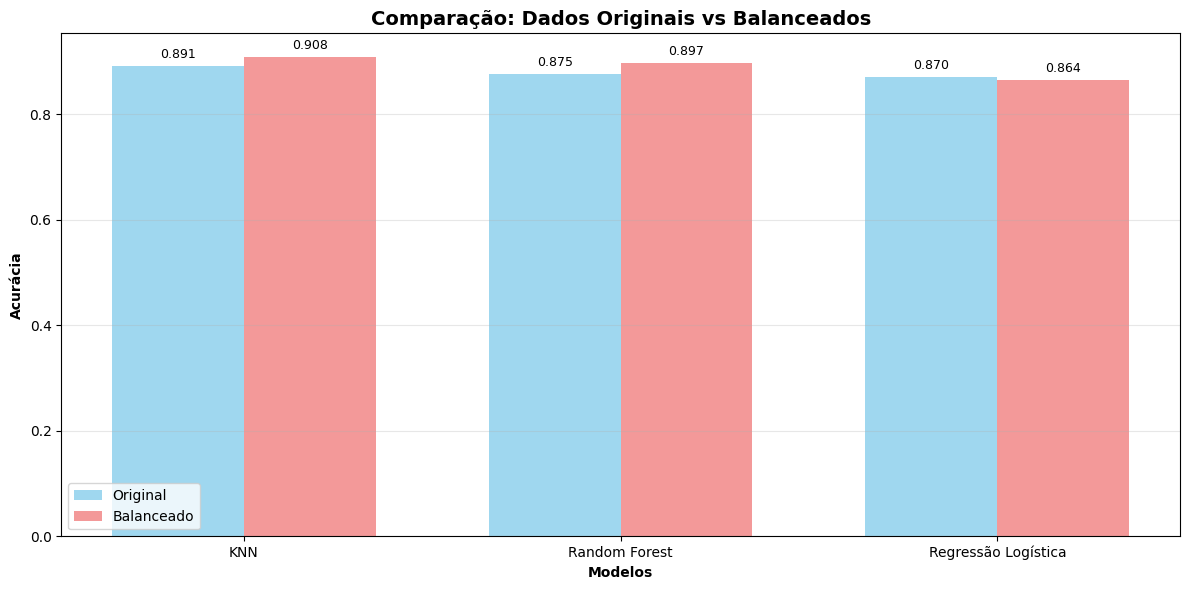

RESUMO ESTATÍSTICO
Média de Acurácia - Original: 0.8786
Média de Acurácia - Balanceado: 0.8895
Diferença Média: 0.0109

Melhor Modelo - Original: KNN (0.8913)
Melhor Modelo - Balanceado: KNN (0.9076)

Análise por Modelo:
   KNN: MELHOROU (+0.0163)
   Random Forest: MELHOROU (+0.0217)
   Regressão Logística: PIOROU (-0.0054)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

df = pd.read_csv('heart.csv')

print(f"Dimensões do dataset: {df.shape}")
print(f"\nDistribuição da variável target (HeartDisease):")
print(df['HeartDisease'].value_counts())

if df.duplicated().sum() > 0:
    df = df.drop_duplicates()

categorical_columns = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino - Shape: {X_train.shape}")
print(f"Distribuição no treino (ORIGINAL):\n{y_train.value_counts()}")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Treino após SMOTE - Shape: {X_train_balanced.shape}")
print(f"Distribuição no treino (BALANCEADO):\n{y_train_balanced.value_counts()}")

results_original = {}
results_balanced = {}
predictions_original = {}
predictions_balanced = {}

def encontrar_melhor_k(X_train_data, y_train_data):
    k_values = range(1, 21)
    cv_accuracies = []

    for k in k_values:
        knn_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('knn', KNeighborsClassifier(n_neighbors=k))
        ])
        scores = cross_val_score(knn_pipeline, X_train_data, y_train_data, cv=5, scoring='accuracy')
        cv_accuracies.append(scores.mean())

    best_k = k_values[np.argmax(cv_accuracies)]
    return best_k, cv_accuracies

print("KNN - DADOS ORIGINAIS")

best_k_original, _ = encontrar_melhor_k(X_train, y_train)
print(f"Melhor K encontrado: {best_k_original}")

knn_original = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k_original))
])
knn_original.fit(X_train, y_train)
y_pred_knn_original = knn_original.predict(X_test)
accuracy_knn_original = accuracy_score(y_test, y_pred_knn_original)

results_original['KNN'] = accuracy_knn_original
predictions_original['KNN'] = y_pred_knn_original

print(f"Acurácia: {accuracy_knn_original:.4f}")

print("KNN - DADOS BALANCEADOS")

best_k_balanced, _ = encontrar_melhor_k(X_train_balanced, y_train_balanced)
print(f"Melhor K encontrado: {best_k_balanced}")

knn_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k_balanced))
])
knn_balanced.fit(X_train_balanced, y_train_balanced)
y_pred_knn_balanced = knn_balanced.predict(X_test)
accuracy_knn_balanced = accuracy_score(y_test, y_pred_knn_balanced)

results_balanced['KNN'] = accuracy_knn_balanced
predictions_balanced['KNN'] = y_pred_knn_balanced

print(f"Acurácia: {accuracy_knn_balanced:.4f}")

print("REGRESSÃO LOGÍSTICA - DADOS ORIGINAIS")

logreg_original = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000))
])
logreg_original.fit(X_train, y_train)
y_pred_logreg_original = logreg_original.predict(X_test)
accuracy_logreg_original = accuracy_score(y_test, y_pred_logreg_original)

results_original['Regressão Logística'] = accuracy_logreg_original
predictions_original['Regressão Logística'] = y_pred_logreg_original

print(f"Acurácia: {accuracy_logreg_original:.4f}")

print("REGRESSÃO LOGÍSTICA - DADOS BALANCEADOS")

logreg_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=1000))
])
logreg_balanced.fit(X_train_balanced, y_train_balanced)
y_pred_logreg_balanced = logreg_balanced.predict(X_test)
accuracy_logreg_balanced = accuracy_score(y_test, y_pred_logreg_balanced)

results_balanced['Regressão Logística'] = accuracy_logreg_balanced
predictions_balanced['Regressão Logística'] = y_pred_logreg_balanced

print(f"Acurácia: {accuracy_logreg_balanced:.4f}")

print("RANDOM FOREST - DADOS ORIGINAIS")

rf_original = RandomForestClassifier(random_state=42, n_estimators=100)
rf_original.fit(X_train, y_train)
y_pred_rf_original = rf_original.predict(X_test)
accuracy_rf_original = accuracy_score(y_test, y_pred_rf_original)

results_original['Random Forest'] = accuracy_rf_original
predictions_original['Random Forest'] = y_pred_rf_original

print(f"Acurácia: {accuracy_rf_original:.4f}")

print("RANDOM FOREST - DADOS BALANCEADOS")

rf_balanced = RandomForestClassifier(random_state=42, n_estimators=100)
rf_balanced.fit(X_train_balanced, y_train_balanced)
y_pred_rf_balanced = rf_balanced.predict(X_test)
accuracy_rf_balanced = accuracy_score(y_test, y_pred_rf_balanced)

results_balanced['Random Forest'] = accuracy_rf_balanced
predictions_balanced['Random Forest'] = y_pred_rf_balanced

print(f"Acurácia: {accuracy_rf_balanced:.4f}")

def criar_matriz_confusao(y_true, y_pred, titulo, nome_arquivo):
    plt.figure(figsize=(8, 6))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['Não Doença', 'Doença'],
               yticklabels=['Não Doença', 'Doença'],
               linewidths=0.5, linecolor='black')

    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    plt.title(f'{titulo}\nAcurácia: {accuracy:.3f}', fontsize=14, fontweight='bold')
    plt.xlabel('Predito', fontweight='bold')
    plt.ylabel('Real', fontweight='bold')

    texto_metricas = f'Precisão: {precision:.3f}\nRecall: {recall:.3f}\nF1-Score: {f1:.3f}'
    plt.text(2.5, 0.5, texto_metricas, fontsize=11,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))


    plt.tight_layout()
    plt.show()

    print(f"\n{titulo}:")
    print(f"   Verdadeiros Negativos (TN): {tn}")
    print(f"   Falsos Positivos (FP): {fp}")
    print(f"   Falsos Negativos (FN): {fn}")
    print(f"   Verdadeiros Positivos (TP): {tp}")
    print(f"   Acurácia: {accuracy:.3f}")
    print(f"   Precisão: {precision:.3f}")
    print(f"   Recall: {recall:.3f}")
    print(f"   F1-Score: {f1:.3f}")
    print("-" * 50)

print("MATRIZES DE CONFUSÃO - DADOS ORIGINAIS")

criar_matriz_confusao(y_test, predictions_original['KNN'],
                     f'KNN - Dados Originais (K={best_k_original})', 'knn_original')

criar_matriz_confusao(y_test, predictions_original['Regressão Logística'],
                     'Regressão Logística - Dados Originais', 'logreg_original')

criar_matriz_confusao(y_test, predictions_original['Random Forest'],
                     'Random Forest - Dados Originais', 'rf_original')

print("MATRIZES DE CONFUSÃO - DADOS BALANCEADOS")

criar_matriz_confusao(y_test, predictions_balanced['KNN'],
                     f'KNN - Dados Balanceados (K={best_k_balanced})', 'knn_balanced')

criar_matriz_confusao(y_test, predictions_balanced['Regressão Logística'],
                     'Regressão Logística - Dados Balanceados', 'logreg_balanced')

criar_matriz_confusao(y_test, predictions_balanced['Random Forest'],
                     'Random Forest - Dados Balanceados', 'rf_balanced')

print("COMPARAÇÃO FINAL - ORIGINAL vs BALANCEADO")

df_original = pd.DataFrame({
    'Modelo': list(results_original.keys()),
    'Acurácia_Original': list(results_original.values())
}).sort_values('Acurácia_Original', ascending=False)

df_balanced = pd.DataFrame({
    'Modelo': list(results_balanced.keys()),
    'Acurácia_Balanceado': list(results_balanced.values())
})

df_comparacao = pd.merge(df_original, df_balanced, on='Modelo')
df_comparacao['Diferença'] = df_comparacao['Acurácia_Balanceado'] - df_comparacao['Acurácia_Original']

print("\nComparação de Acurácia:")
print(df_comparacao)

plt.figure(figsize=(12, 6))
x = np.arange(len(df_comparacao))
width = 0.35

plt.bar(x - width/2, df_comparacao['Acurácia_Original'], width, label='Original', alpha=0.8, color='skyblue')
plt.bar(x + width/2, df_comparacao['Acurácia_Balanceado'], width, label='Balanceado', alpha=0.8, color='lightcoral')

plt.xlabel('Modelos', fontweight='bold')
plt.ylabel('Acurácia', fontweight='bold')
plt.title('Comparação: Dados Originais vs Balanceados', fontsize=14, fontweight='bold')
plt.xticks(x, df_comparacao['Modelo'])
plt.legend()
plt.grid(axis='y', alpha=0.3)

for i, (orig, bal) in enumerate(zip(df_comparacao['Acurácia_Original'], df_comparacao['Acurácia_Balanceado'])):
    plt.text(i - width/2, orig + 0.01, f'{orig:.3f}', ha='center', va='bottom', fontsize=9)
    plt.text(i + width/2, bal + 0.01, f'{bal:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("RESUMO ESTATÍSTICO")

media_original = df_comparacao['Acurácia_Original'].mean()
media_balanceado = df_comparacao['Acurácia_Balanceado'].mean()
melhor_modelo_original = df_comparacao.loc[df_comparacao['Acurácia_Original'].idxmax()]
melhor_modelo_balanceado = df_comparacao.loc[df_comparacao['Acurácia_Balanceado'].idxmax()]

print(f"Média de Acurácia - Original: {media_original:.4f}")
print(f"Média de Acurácia - Balanceado: {media_balanceado:.4f}")
print(f"Diferença Média: {media_balanceado - media_original:.4f}")

print(f"\nMelhor Modelo - Original: {melhor_modelo_original['Modelo']} ({melhor_modelo_original['Acurácia_Original']:.4f})")
print(f"Melhor Modelo - Balanceado: {melhor_modelo_balanceado['Modelo']} ({melhor_modelo_balanceado['Acurácia_Balanceado']:.4f})")

print(f"\nAnálise por Modelo:")
for _, row in df_comparacao.iterrows():
    status = "MELHOROU" if row['Diferença'] > 0 else "PIOROU" if row['Diferença'] < 0 else "MANTEVE"
    print(f"   {row['Modelo']}: {status} ({row['Diferença']:+.4f})")